In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'


CR_COLORS = ['#FFD700', '#FF6B35', '#004E89', '#A8DADC', '#E63946',
             '#06D6A0', '#118AB2', '#9B5DE5', '#F15BB5', '#00BBF9']

print(" Libraries imported & styling configured!")

 Libraries imported & styling configured!


In [2]:

PROCESSED_PATH = Path("../dataset/processed/")

cards_df = pd.read_csv(PROCESSED_PATH / "cards_cleaned.csv")
decks_df = pd.read_csv(PROCESSED_PATH / "decks_cleaned.csv")
battles_df = pd.read_csv(PROCESSED_PATH / "battles_cleaned.csv")
meta_df = pd.read_csv(PROCESSED_PATH / "meta_cleaned.csv")

print("All cleaned datasets loaded!\n")
print(f"Cards:    {cards_df.shape}")
print(f"Decks:    {decks_df.shape}")
print(f"Battles:  {battles_df.shape}")
print(f"Meta:     {meta_df.shape}")

All cleaned datasets loaded!

Cards:    (121, 16)
Decks:    (480, 18)
Battles:  (5000, 15)
Meta:     (635, 6)


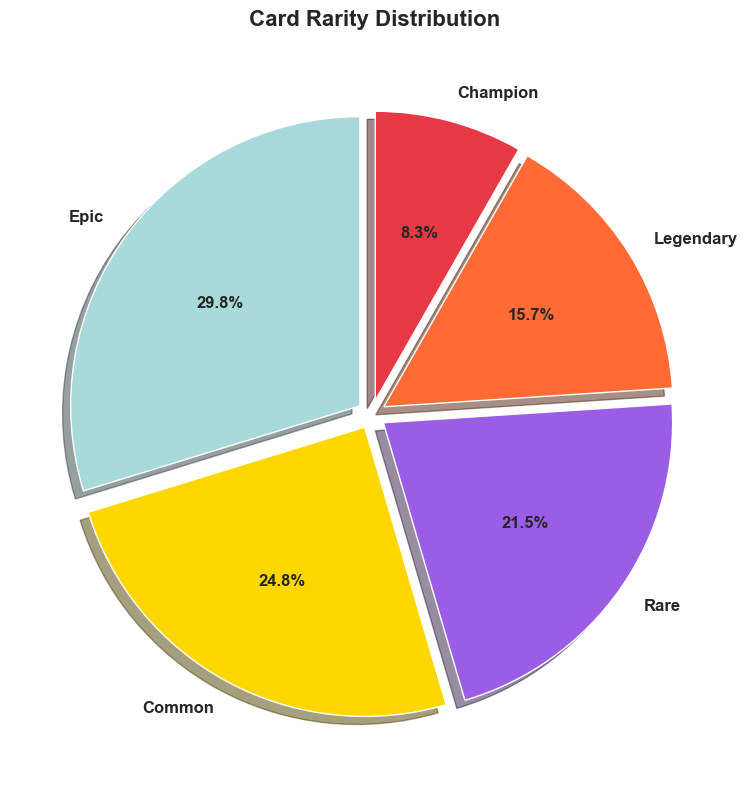


 Rarity Breakdown:
rarity
Epic         36
Common       30
Rare         26
Legendary    19
Champion     10
Name: count, dtype: int64


In [3]:

rarity_counts = cards_df['rarity'].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#A8DADC', '#FFD700', '#9B5DE5', '#FF6B35', '#E63946']

wedges, texts, autotexts = ax.pie(
    rarity_counts.values,
    labels=rarity_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=[0.05] * len(rarity_counts),
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

ax.set_title(' Card Rarity Distribution', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n Rarity Breakdown:")
print(rarity_counts)

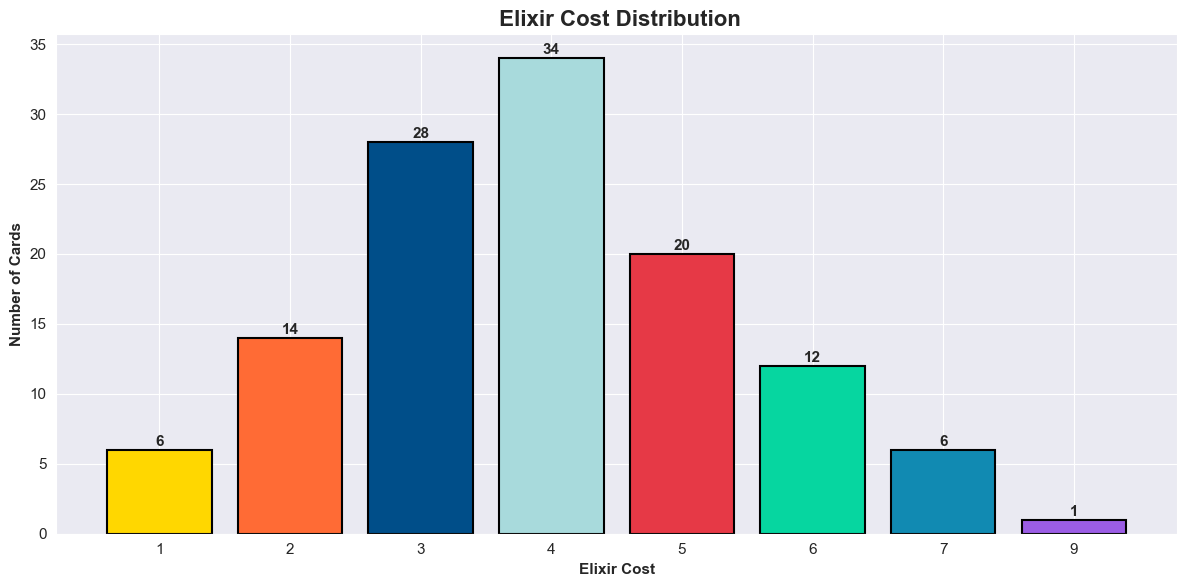

In [4]:

fig, ax = plt.subplots(figsize=(12, 6))

elixir_counts = cards_df['elixir_cost'].value_counts().sort_index()

bars = ax.bar(
    elixir_counts.index.astype(str),
    elixir_counts.values,
    color=CR_COLORS[:len(elixir_counts)],
    edgecolor='black',
    linewidth=1.5
)


for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
            f'{int(height)}', ha='center', fontweight='bold', fontsize=11)

ax.set_title(' Elixir Cost Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Elixir Cost', fontweight='bold')
ax.set_ylabel('Number of Cards', fontweight='bold')
plt.tight_layout()
plt.show()

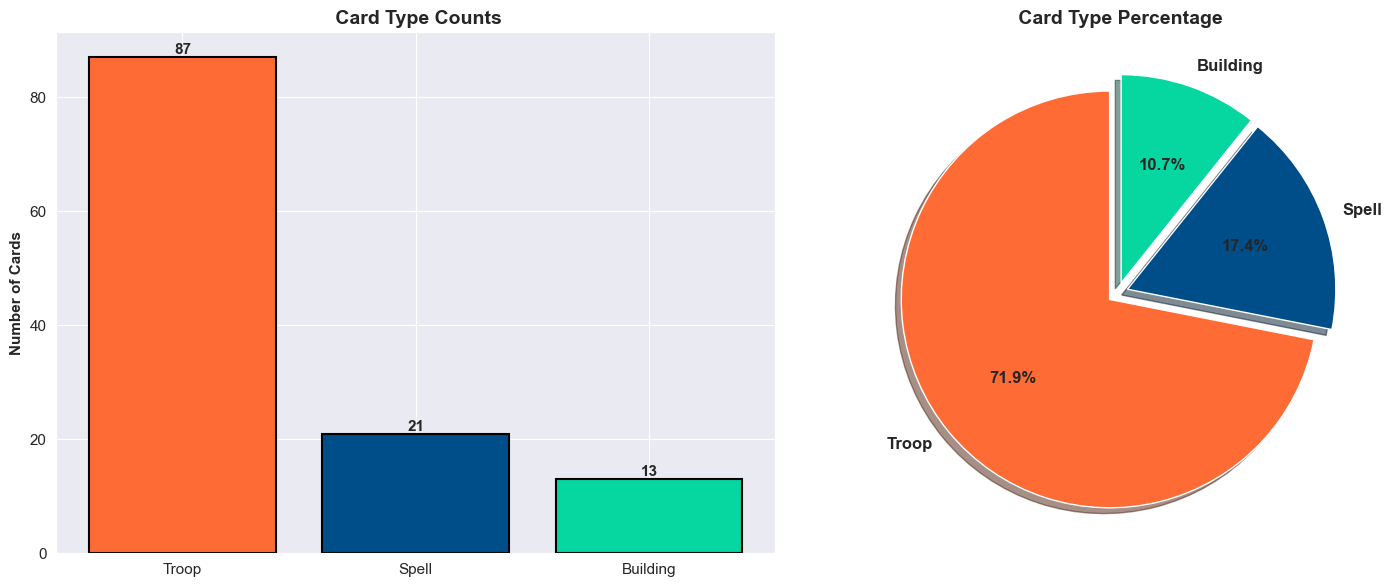

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))


type_counts = cards_df['type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values,
            color=['#FF6B35', '#004E89', '#06D6A0'],
            edgecolor='black', linewidth=1.5)
axes[0].set_title(' Card Type Counts', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Cards', fontweight='bold')

for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')


axes[1].pie(type_counts.values, labels=type_counts.index,
            autopct='%1.1f%%', colors=['#FF6B35', '#004E89', '#06D6A0'],
            startangle=90, explode=[0.05]*3, shadow=True,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title(' Card Type Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

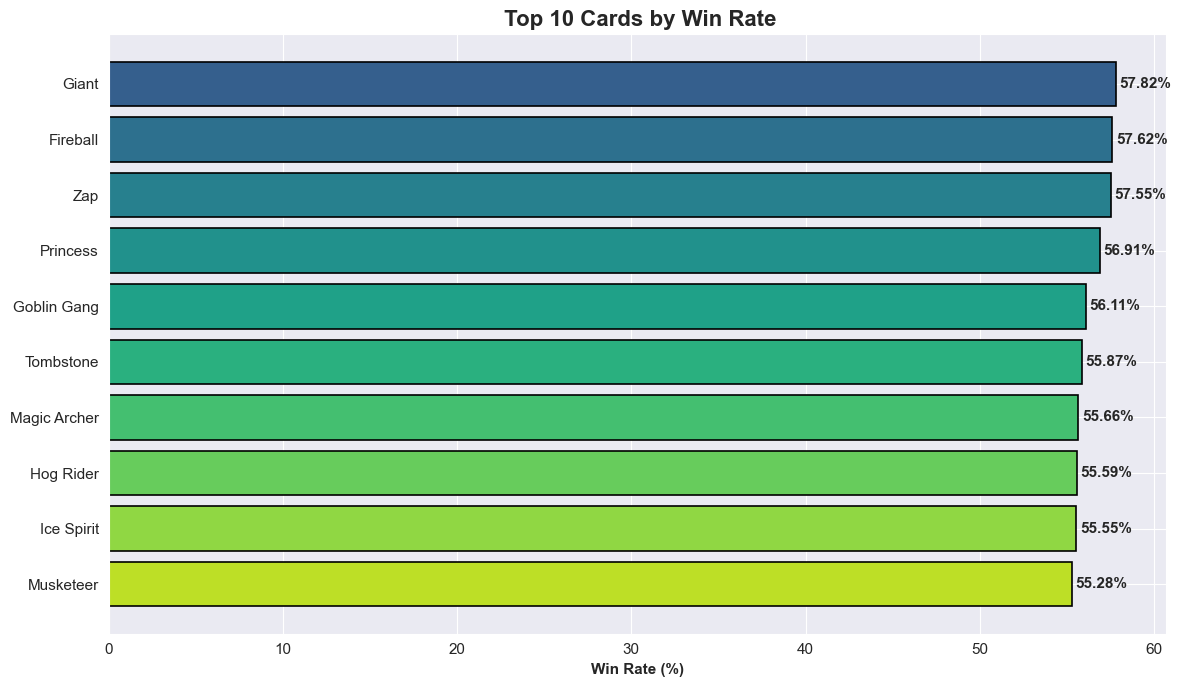

In [6]:

top_win = cards_df.nlargest(10, 'win_rate')[['name', 'win_rate', 'rarity']]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_win['name'], top_win['win_rate'],
               color=plt.cm.viridis(np.linspace(0.3, 0.9, 10)),
               edgecolor='black', linewidth=1.2)

for bar, val in zip(bars, top_win['win_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontweight='bold')

ax.set_title(' Top 10 Cards by Win Rate', fontsize=16, fontweight='bold')
ax.set_xlabel('Win Rate (%)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

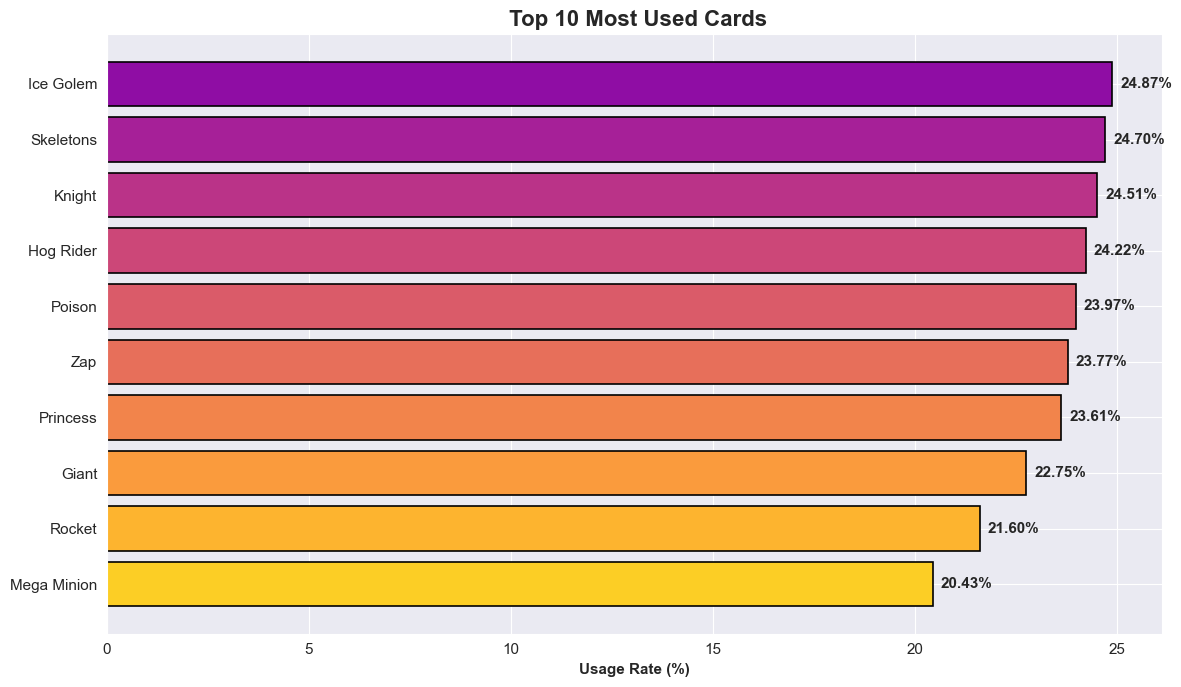

In [7]:

top_usage = cards_df.nlargest(10, 'usage_rate')[['name', 'usage_rate', 'rarity']]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_usage['name'], top_usage['usage_rate'],
               color=plt.cm.plasma(np.linspace(0.3, 0.9, 10)),
               edgecolor='black', linewidth=1.2)

for bar, val in zip(bars, top_usage['usage_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontweight='bold')

ax.set_title(' Top 10 Most Used Cards', fontsize=16, fontweight='bold')
ax.set_xlabel('Usage Rate (%)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

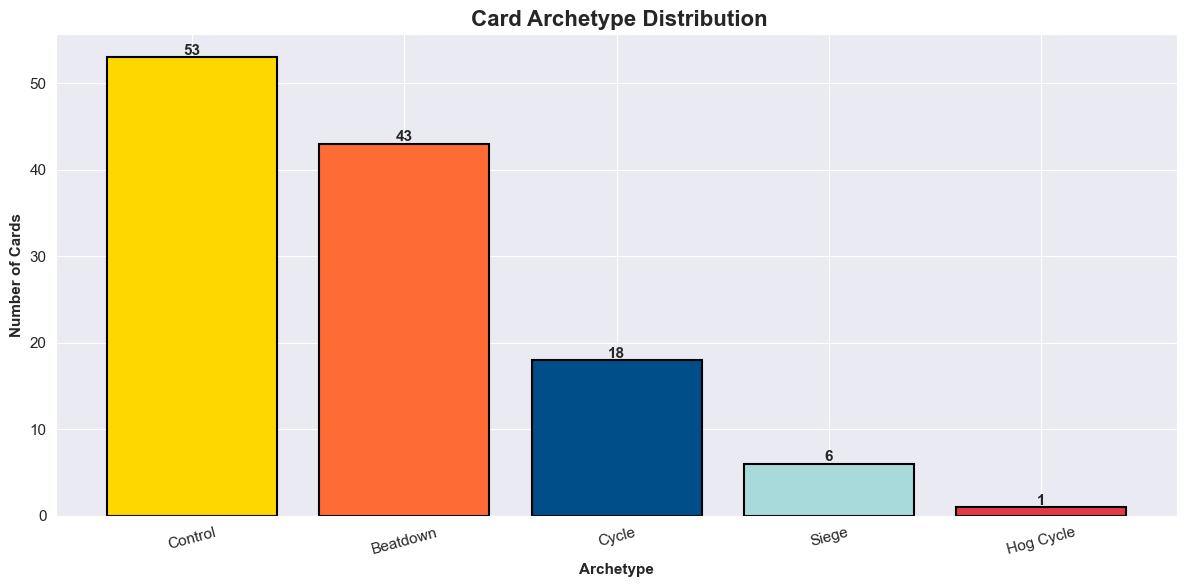

In [8]:

archetype_counts = cards_df['archetype'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(archetype_counts.index, archetype_counts.values,
              color=CR_COLORS[:len(archetype_counts)],
              edgecolor='black', linewidth=1.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
            f'{int(height)}', ha='center', fontweight='bold', fontsize=11)

ax.set_title(' Card Archetype Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Archetype', fontweight='bold')
ax.set_ylabel('Number of Cards', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

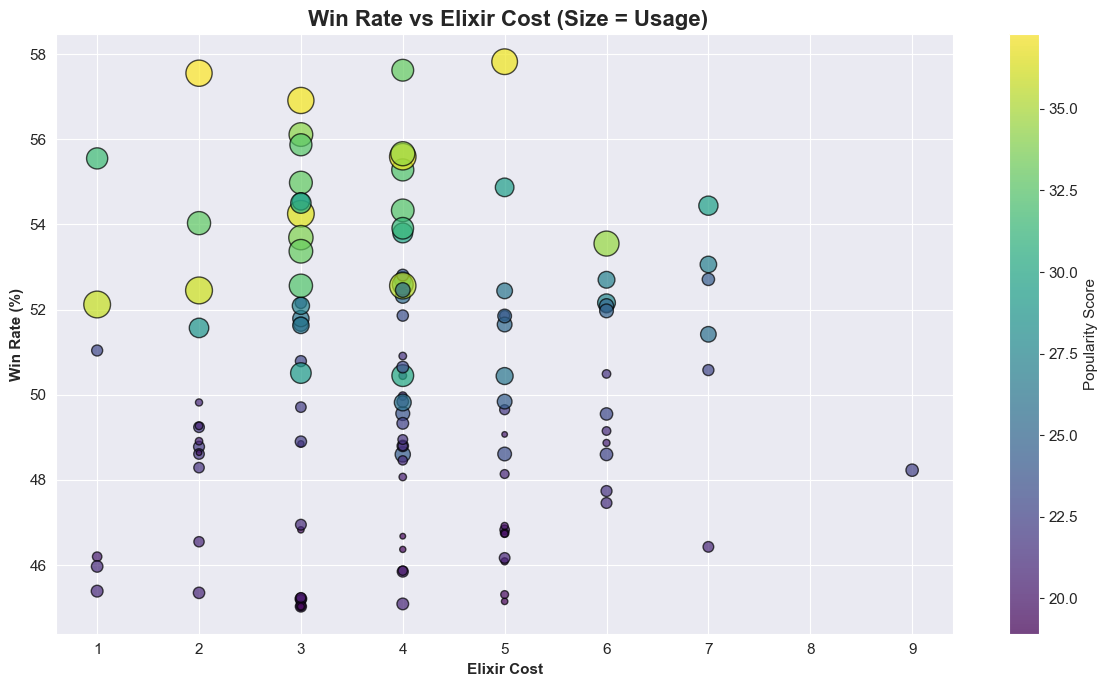

In [9]:

fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    cards_df['elixir_cost'],
    cards_df['win_rate'],
    s=cards_df['usage_rate'] * 15,  # size = usage
    c=cards_df['popularity_score'],
    cmap='viridis',
    alpha=0.7,
    edgecolors='black',
    linewidth=1
)

plt.colorbar(scatter, label='Popularity Score')
ax.set_title(' Win Rate vs Elixir Cost (Size = Usage)', fontsize=16, fontweight='bold')
ax.set_xlabel('Elixir Cost', fontweight='bold')
ax.set_ylabel('Win Rate (%)', fontweight='bold')
plt.tight_layout()
plt.show()

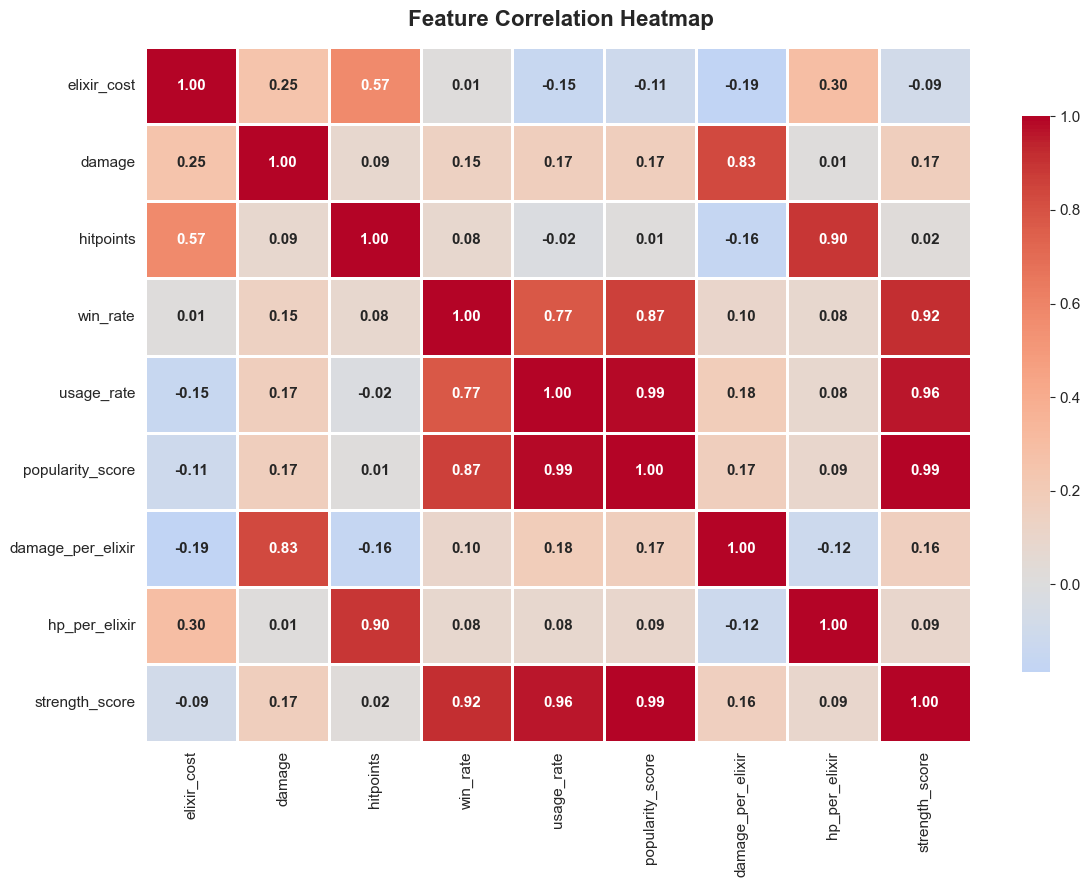

In [10]:

numeric_cols = ['elixir_cost', 'damage', 'hitpoints', 'win_rate',
                'usage_rate', 'popularity_score', 'damage_per_elixir',
                'hp_per_elixir', 'strength_score']

corr_matrix = cards_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=1,
    cbar_kws={'shrink': 0.8},
    annot_kws={'fontweight': 'bold'}
)

plt.title(' Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

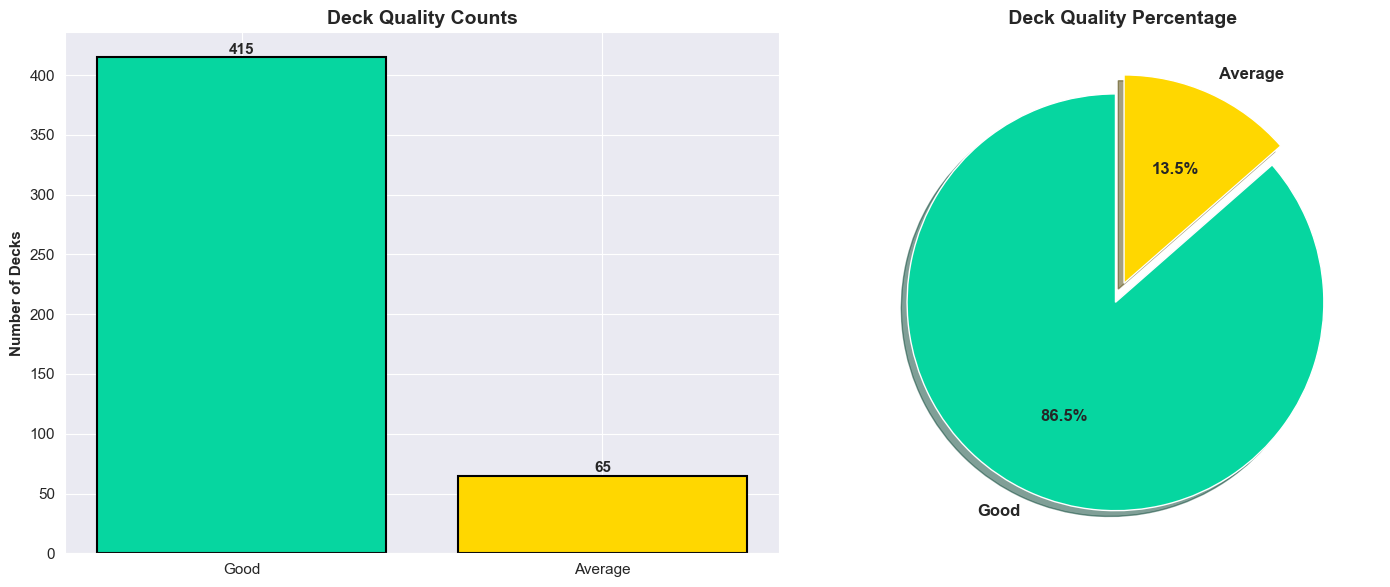

In [11]:

quality_counts = decks_df['quality'].value_counts()
quality_order = ['Excellent', 'Good', 'Average', 'Weak']
quality_counts = quality_counts.reindex([q for q in quality_order if q in quality_counts.index])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar
colors = ['#06D6A0', '#FFD700', '#FF6B35', '#E63946']
axes[0].bar(quality_counts.index, quality_counts.values,
            color=colors[:len(quality_counts)], edgecolor='black', linewidth=1.5)
axes[0].set_title('Deck Quality Counts', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Decks', fontweight='bold')

for i, v in enumerate(quality_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Pie
axes[1].pie(quality_counts.values, labels=quality_counts.index,
            autopct='%1.1f%%', colors=colors[:len(quality_counts)],
            startangle=90, explode=[0.05]*len(quality_counts), shadow=True,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title(' Deck Quality Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

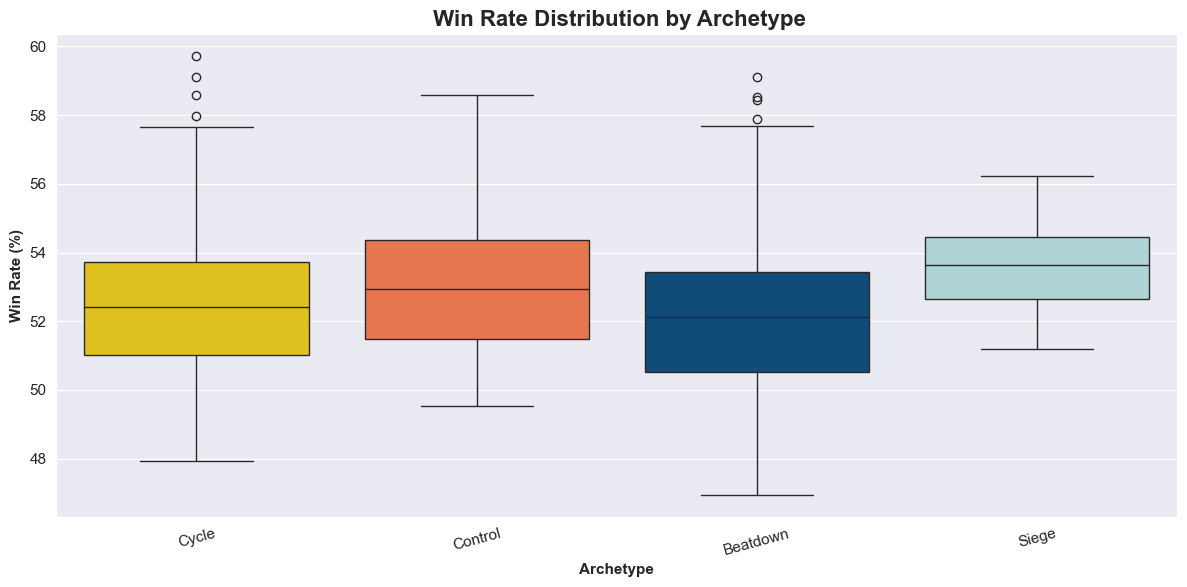

In [12]:

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=decks_df, x='archetype', y='win_rate',
            palette=CR_COLORS, ax=ax)

ax.set_title(' Win Rate Distribution by Archetype', fontsize=16, fontweight='bold')
ax.set_xlabel('Archetype', fontweight='bold')
ax.set_ylabel('Win Rate (%)', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

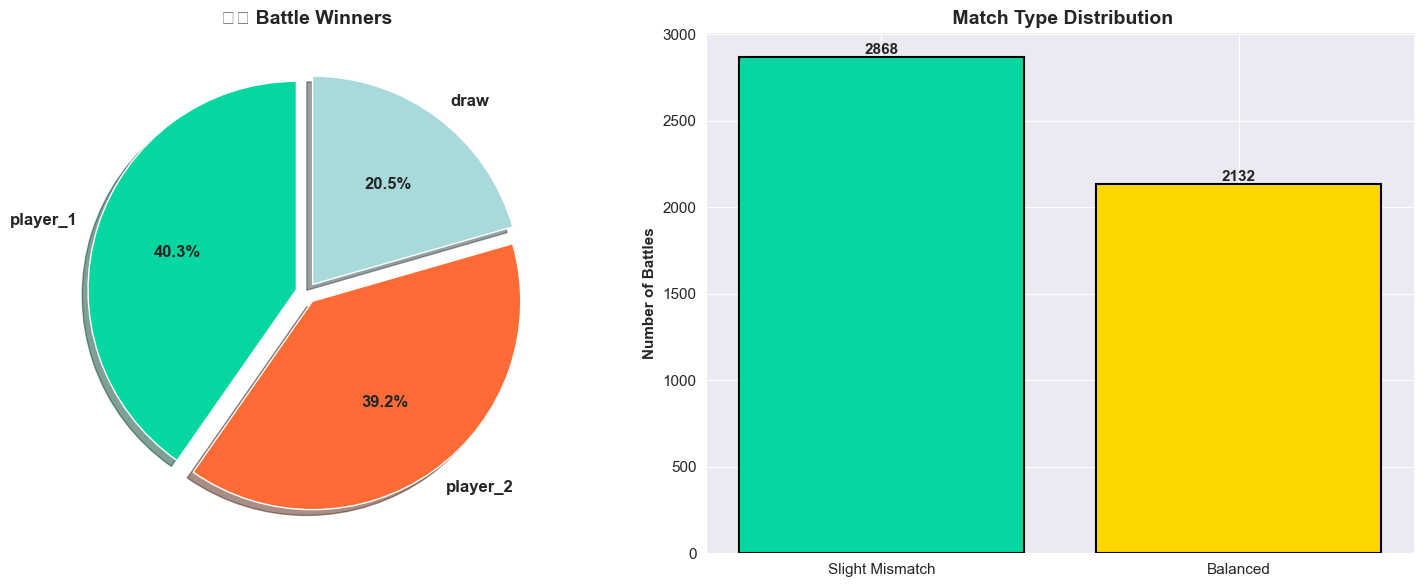

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))


winner_counts = battles_df['winner'].value_counts()
axes[0].pie(winner_counts.values, labels=winner_counts.index,
            autopct='%1.1f%%',
            colors=['#06D6A0', '#FF6B35', '#A8DADC'],
            startangle=90, explode=[0.05]*len(winner_counts), shadow=True,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[0].set_title('⚔️ Battle Winners', fontsize=14, fontweight='bold')

match_counts = battles_df['match_type'].value_counts()
axes[1].bar(match_counts.index, match_counts.values,
            color=['#06D6A0', '#FFD700', '#E63946'], edgecolor='black', linewidth=1.5)
axes[1].set_title(' Match Type Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Battles', fontweight='bold')

for i, v in enumerate(match_counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

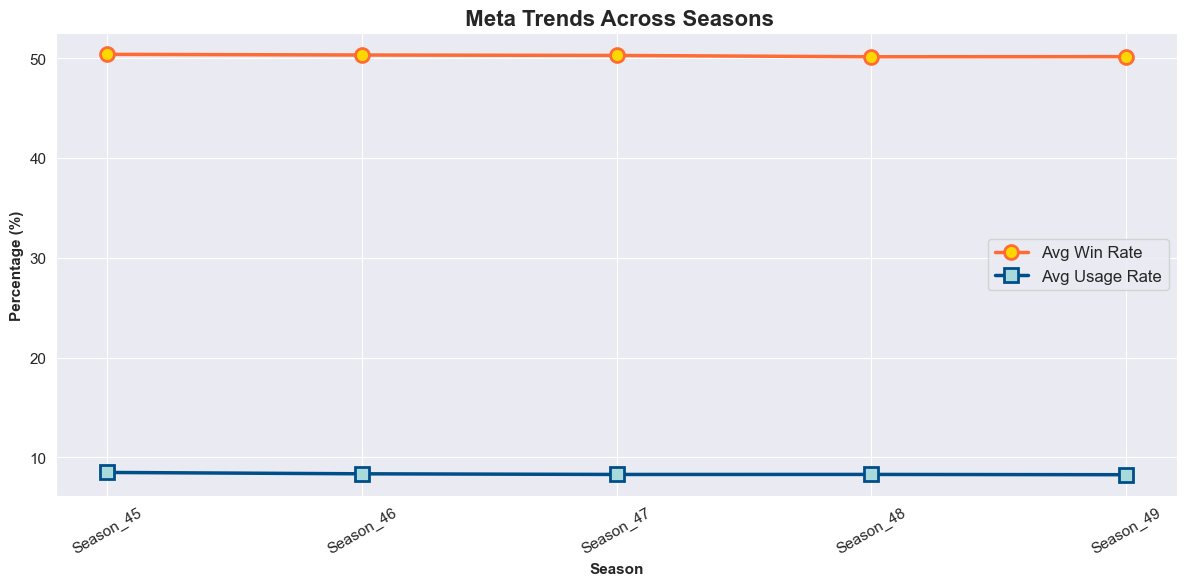

In [14]:

seasonal_avg = meta_df.groupby('season').agg(
    avg_win_rate=('win_rate', 'mean'),
    avg_usage=('usage_rate', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(seasonal_avg['season'], seasonal_avg['avg_win_rate'],
        marker='o', linewidth=2.5, markersize=10, color='#FF6B35',
        label='Avg Win Rate', markerfacecolor='#FFD700', markeredgewidth=2)

ax.plot(seasonal_avg['season'], seasonal_avg['avg_usage'],
        marker='s', linewidth=2.5, markersize=10, color='#004E89',
        label='Avg Usage Rate', markerfacecolor='#A8DADC', markeredgewidth=2)

ax.set_title(' Meta Trends Across Seasons', fontsize=16, fontweight='bold')
ax.set_xlabel('Season', fontweight='bold')
ax.set_ylabel('Percentage (%)', fontweight='bold')
ax.legend(fontsize=12, loc='best')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [15]:
#
print("=" * 70)
print(" EDA KEY INSIGHTS")
print("=" * 70)

best_card = cards_df.loc[cards_df['win_rate'].idxmax()]
most_used = cards_df.loc[cards_df['usage_rate'].idxmax()]
best_deck = decks_df.loc[decks_df['win_rate'].idxmax()]
best_archetype = decks_df.groupby('archetype')['win_rate'].mean().idxmax()

print(f"""
 BEST CARD (Win Rate):    {best_card['name']} ({best_card['win_rate']:.2f}%)
 MOST USED CARD:          {most_used['name']} ({most_used['usage_rate']:.2f}%)
 BEST DECK ID:            #{best_deck['deck_id']} ({best_deck['win_rate']:.2f}%)
 BEST ARCHETYPE:          {best_archetype}

 Average Elixir Cost:     {cards_df['elixir_cost'].mean():.2f}
 Average Win Rate:        {cards_df['win_rate'].mean():.2f}%
  Total Battles Analyzed:  {len(battles_df):,}

 NEXT STEP: Notebook 04 - Feature Engineering & ML Model Training!
""")

 EDA KEY INSIGHTS

 BEST CARD (Win Rate):    Giant (57.82%)
 MOST USED CARD:          Ice Golem (24.87%)
 BEST DECK ID:            #240 (59.71%)
 BEST ARCHETYPE:          Siege

 Average Elixir Cost:     3.94
 Average Win Rate:        50.32%
  Total Battles Analyzed:  5,000

 NEXT STEP: Notebook 04 - Feature Engineering & ML Model Training!

